In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")


In [8]:
data =pd.read_csv("eurusd.csv",parse_dates=["Date"],index_col=["Date"])

In [9]:
sma_50=50
sma_200=200

In [10]:
data

,price
Date,
2004-01-01,1.258194
2004-01-02,1.258194
2004-01-05,1.268698
2004-01-06,1.272103
2004-01-07,1.264095
...,...
2020-06-24,1.131235
2020-06-25,1.125087
2020-06-26,1.122208


In [12]:
data["sma_50"] = data.price.rolling(sma_50).mean()

In [13]:
data["sma_200"] = data.price.rolling(sma_200).mean()

In [14]:
data

,price,SMA_50,sma_200
Date,,,
2004-01-01,1.258194,NaN,NaN
2004-01-02,1.258194,NaN,NaN
2004-01-05,1.268698,NaN,NaN
2004-01-06,1.272103,NaN,NaN
2004-01-07,1.264095,NaN,NaN
...,...,...,...
2020-06-24,1.131235,1.101794,1.103430
2020-06-25,1.125087,1.102486,1.103540
2020-06-26,1.122208,1.103213,1.103627


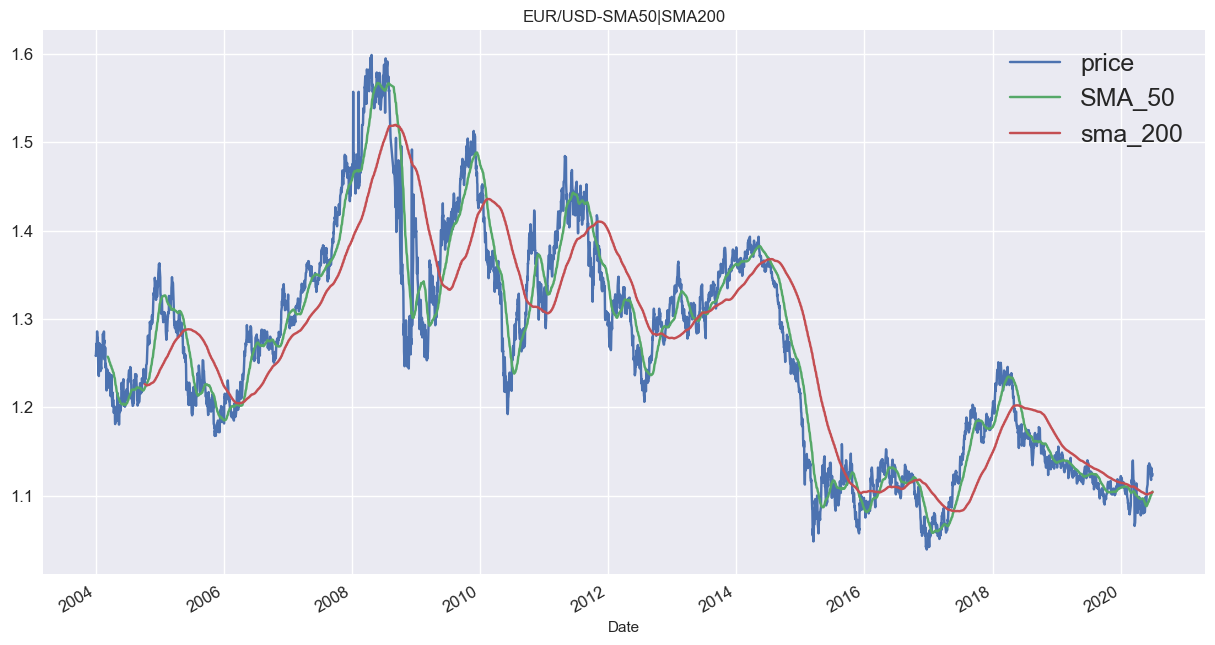

In [17]:
data.plot(figsize=(15,8),title = "EUR/USD-SMA{}|SMA{}".format(sma_50,sma_200),fontsize=12)
plt.legend(fontsize=18)
plt.show()

In [18]:
data.dropna(inplace=True)

In [19]:
data

,price,SMA_50,sma_200
Date,,,
2004-10-06,1.228094,1.221318,1.226222
2004-10-07,1.229906,1.221840,1.226081
2004-10-08,1.241003,1.222628,1.225995
2004-10-11,1.238405,1.223352,1.225843
2004-10-12,1.232104,1.223888,1.225643
...,...,...,...
2020-06-24,1.131235,1.101794,1.103430
2020-06-25,1.125087,1.102486,1.103540
2020-06-26,1.122208,1.103213,1.103627


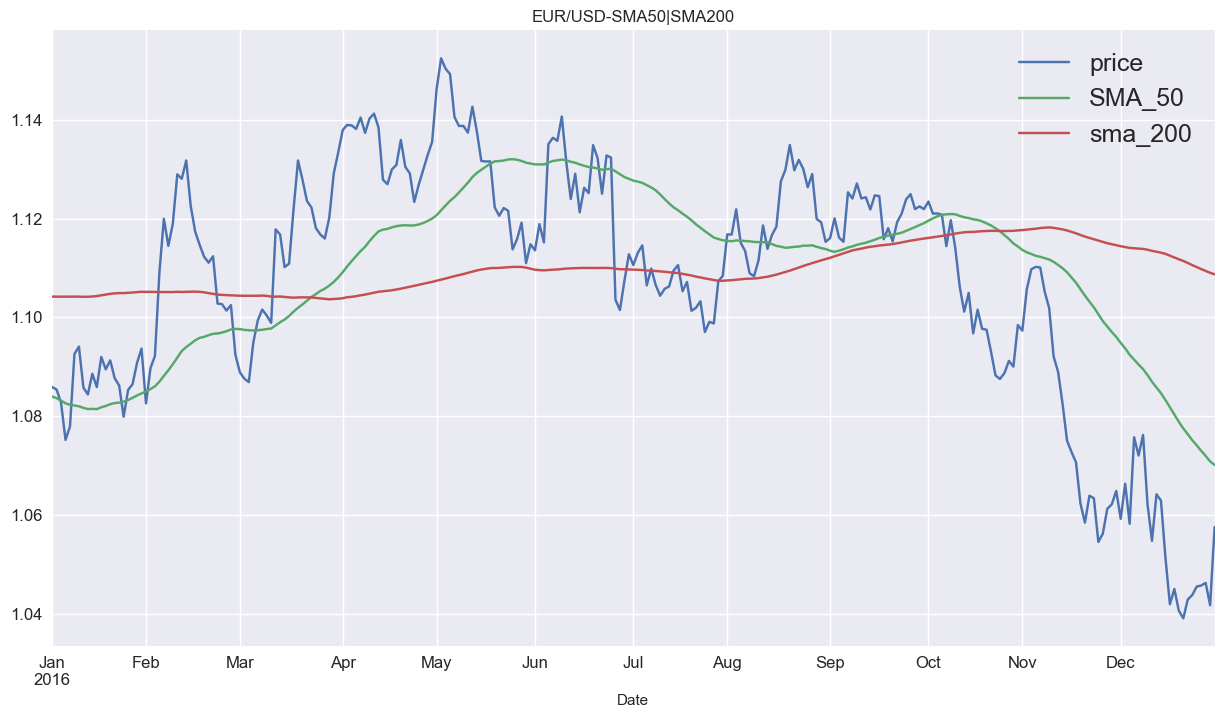

In [28]:
data.loc["2016"].plot(figsize=(15,8),title = "EUR/USD-SMA{}|SMA{}".format(sma_50,sma_200),fontsize=12)
plt.legend(fontsize=18)
plt.show()

In [33]:
data["position"] = np.where(data["SMA_50"]>data["sma_200"],1,-1)
data

,price,SMA_50,sma_200,position
Date,,,,
2004-10-06,1.228094,1.221318,1.226222,-1
2004-10-07,1.229906,1.221840,1.226081,-1
2004-10-08,1.241003,1.222628,1.225995,-1
2004-10-11,1.238405,1.223352,1.225843,-1
2004-10-12,1.232104,1.223888,1.225643,-1
...,...,...,...,...
2020-06-24,1.131235,1.101794,1.103430,-1
2020-06-25,1.125087,1.102486,1.103540,-1
2020-06-26,1.122208,1.103213,1.103627,-1


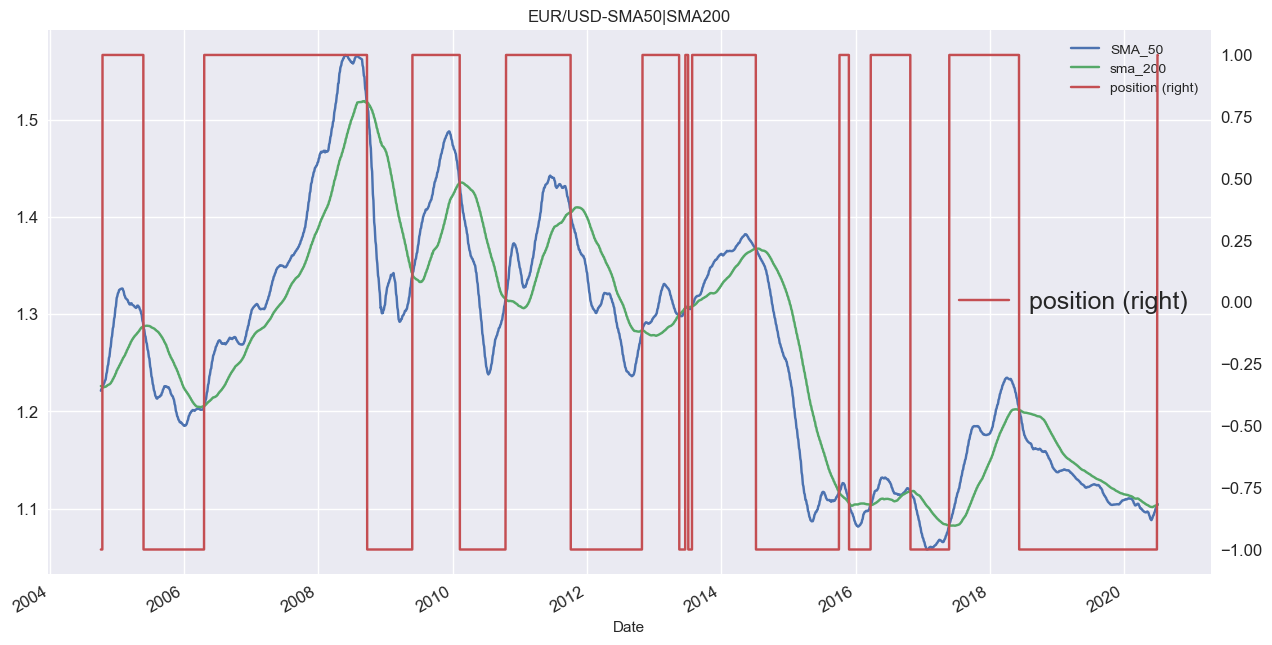

In [38]:
data.loc[:,["SMA_50","sma_200","position"]].plot(figsize=(15,8),secondary_y="position",title = "EUR/USD-SMA{}|SMA{}".format(sma_50,sma_200),fontsize=12)
plt.legend(fontsize=18)
plt.show()

In [39]:
data


,price,SMA_50,sma_200,position
Date,,,,
2004-10-06,1.228094,1.221318,1.226222,-1
2004-10-07,1.229906,1.221840,1.226081,-1
2004-10-08,1.241003,1.222628,1.225995,-1
2004-10-11,1.238405,1.223352,1.225843,-1
2004-10-12,1.232104,1.223888,1.225643,-1
...,...,...,...,...
2020-06-24,1.131235,1.101794,1.103430,-1
2020-06-25,1.125087,1.102486,1.103540,-1
2020-06-26,1.122208,1.103213,1.103627,-1


In [41]:
data["returns"] = np.log(data.price.div(data.price.shift(1)))
data

,price,SMA_50,sma_200,position,returns
Date,,,,,
2004-10-06,1.228094,1.221318,1.226222,-1,NaN
2004-10-07,1.229906,1.221840,1.226081,-1,0.001475
2004-10-08,1.241003,1.222628,1.225995,-1,0.008982
2004-10-11,1.238405,1.223352,1.225843,-1,-0.002095
2004-10-12,1.232104,1.223888,1.225643,-1,-0.005102
...,...,...,...,...,...
2020-06-24,1.131235,1.101794,1.103430,-1,0.002892
2020-06-25,1.125087,1.102486,1.103540,-1,-0.005449
2020-06-26,1.122208,1.103213,1.103627,-1,-0.002562


In [43]:
data["startegy"] = data.position.shift(1)*data["returns"]
data

,price,SMA_50,sma_200,position,returns,startegy
Date,,,,,,
2004-10-06,1.228094,1.221318,1.226222,-1,NaN,NaN
2004-10-07,1.229906,1.221840,1.226081,-1,0.001475,-0.001475
2004-10-08,1.241003,1.222628,1.225995,-1,0.008982,-0.008982
2004-10-11,1.238405,1.223352,1.225843,-1,-0.002095,0.002095
2004-10-12,1.232104,1.223888,1.225643,-1,-0.005102,0.005102
...,...,...,...,...,...,...
2020-06-24,1.131235,1.101794,1.103430,-1,0.002892,-0.002892
2020-06-25,1.125087,1.102486,1.103540,-1,-0.005449,0.005449
2020-06-26,1.122208,1.103213,1.103627,-1,-0.002562,0.002562


In [44]:
data.dropna(inplace=True)

In [46]:
data[["returns","startegy"]].sum()

returns    -0.087929
startegy    0.249591
dtype: float64

In [48]:
data[["returns","startegy"]].sum().apply(np.exp)

returns     0.915826
startegy    1.283500
dtype: float64

In [49]:
data[["returns","startegy"]].mean()

returns    -0.000022
startegy    0.000061
dtype: float64

In [51]:
data[["returns","startegy"]].std()*np.sqrt(252)

returns     0.120806
startegy    0.120802
dtype: float64

In [52]:
data["creturns"] =data["returns"].cumsum().apply(np.exp)
data["cstrategy"] = data["startegy"].cumsum().apply(np.exp)

In [53]:
data

,price,SMA_50,sma_200,position,returns,startegy,creturns,cstrategy
Date,,,,,,,,
2004-10-07,1.229906,1.221840,1.226081,-1,0.001475,-0.001475,1.001476,0.998526
2004-10-08,1.241003,1.222628,1.225995,-1,0.008982,-0.008982,1.010511,0.989598
2004-10-11,1.238405,1.223352,1.225843,-1,-0.002095,0.002095,1.008396,0.991673
2004-10-12,1.232104,1.223888,1.225643,-1,-0.005102,0.005102,1.003265,0.996746
2004-10-13,1.234903,1.224466,1.225497,-1,0.002270,-0.002270,1.005545,0.994486
...,...,...,...,...,...,...,...,...
2020-06-24,1.131235,1.101794,1.103430,-1,0.002892,-0.002892,0.921130,1.271272
2020-06-25,1.125087,1.102486,1.103540,-1,-0.005449,0.005449,0.916125,1.278218
2020-06-26,1.122208,1.103213,1.103627,-1,-0.002562,0.002562,0.913781,1.281497


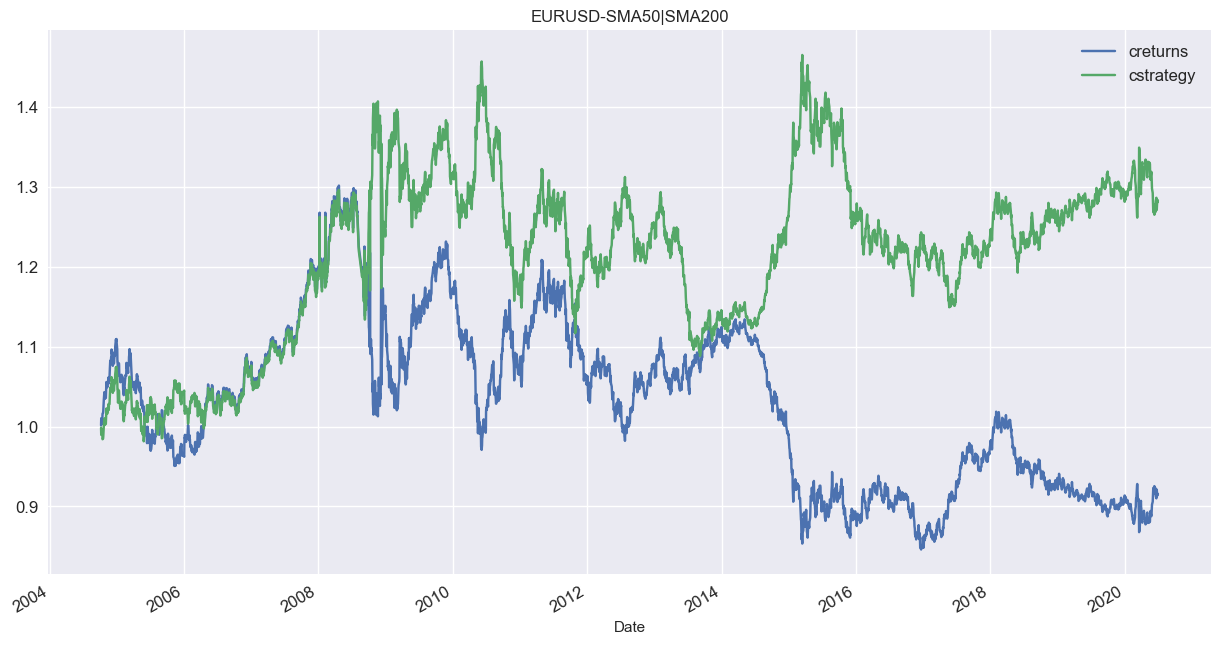

In [58]:
data[["creturns","cstrategy"]].plot(figsize=(15,8),title = "EURUSD-SMA{}|SMA{}".format(sma_50,sma_200),fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [61]:
outperforms = data.cstrategy.iloc[-1]-data.creturns.iloc[-1]
outperforms

np.float64(0.3676743925451291)